In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
dataset=pd.read_csv("Downloads/iris.csv")
dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
dataset["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
#slice the dataset as descriptive and target variable
x=dataset.iloc[:,[2,3]].values
y=dataset.iloc[:,4].values
print(y)
print(np.shape(x))
print(dataset.head())

['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor

In [6]:
#splitting tha dataset into train and test model
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)

In [7]:
#create a decision tree classifier object
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=2,min_samples_split=5,min_samples_leaf=5)


In [8]:
# train the model 
model.fit(x_train,y_train)
print(model)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=5, min_samples_split=5)


In [11]:
#predict the testing model
y_pred=model.predict(x_test)
y_pred

array(['Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica'], dtype=object)

In [12]:
#confusion matrix
from sklearn.metrics import confusion_matrix
c=confusion_matrix(y_test,y_pred)
c


array([[16,  0,  0],
       [ 0, 18,  1],
       [ 0,  3, 12]], dtype=int64)

In [13]:
print(len(y_test))

50


In [14]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.92


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        16
Iris-versicolor       0.86      0.95      0.90        19
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.92        50
      macro avg       0.93      0.92      0.92        50
   weighted avg       0.92      0.92      0.92        50



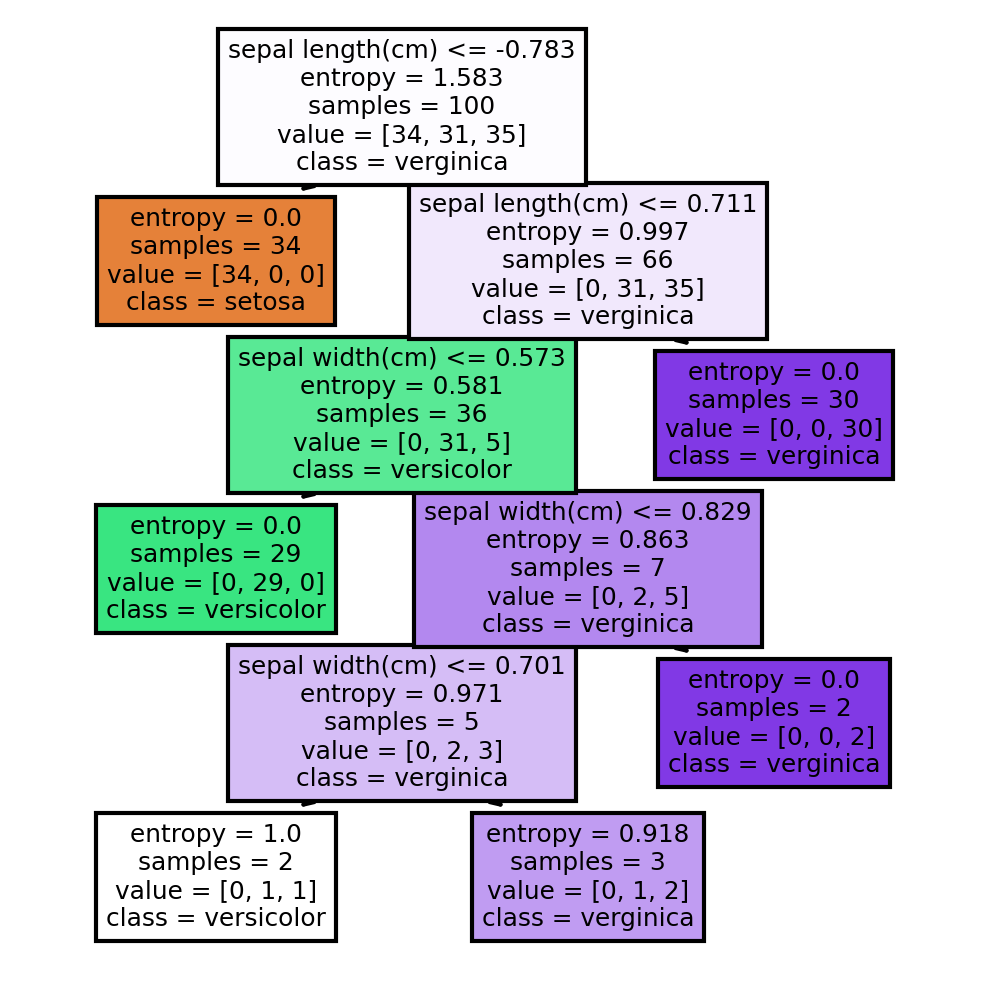

In [30]:
# visualization
from sklearn import tree
fn=["sepal length(cm)","sepal width(cm)","petal length(cm)","petal width(cm)"]
cn=["setosa","versicolor","verginica"]
fig,axis=plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=300)
tree.plot_tree(model,#object created for decission tree classifier
               feature_names=fn,#column names
               class_names=cn,#label names
               filled=True);

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
from sklearn.metrics import confusion_matrix,accuracy_score
cmnb = confusion_matrix(y_test, y_pred_nb)
print(cmnb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)



[[16  0  0]
 [ 0 18  1]
 [ 0  1 14]]
Accuracy: 0.96


In [38]:
#Support vector machine(svc)-regression,clasification
from sklearn.svm import SVC #svc-classification,svr-regression
#Create SVM classifier object
#model=SVC(kernel="rbf",C=10,gamma="scale",random-state=0)
#model=SVC(kernel"linear")#hyperparameter tuning
model=SVC(kernel="poly",degree=3)
#model=SVC(kernel="rbf")
#training the model 
model.fit(x_train,y_train)
print(model)


SVC(kernel='poly')


In [39]:
#prdicting the test set results
y_pred_svm=model.predict(x_test)
print(y_pred_svm)

['Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-versicolor' 'Iris-virginica']


In [41]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm_svc=confusion_matrix(y_test,y_pred_svm)
print(cm_svc)

[[16  0  0]
 [ 0 18  1]
 [ 0  2 13]]


DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                       min_samples_split=5)


array(['Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica'],
      dtype=object)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        16
Iris-versicolor       0.86      0.95      0.90        19
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.92        50
      macro avg       0.93      0.92      0.92        50
   weighted avg       0.92      0.92      0.92        50



In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_Train,y_Train)
y_pred_nb = nb.predict(x_Test)
cmnb = confusion_matrix(y_Test, y_pred_nb)
print(cmnb)
accuracy_nb = accuracy_score(Y_Test, y_pred_nb)
print("Accuracy:", accuracy_nb)



NameError: name 'x_Train' is not defined

In [20]:
#support vector machine(SVM)-regression,clasification
from sklearn.svm import SVC #svc-classification,svr-regression
#Create SVM classifier object
#model=SVC(kernel="rbf",C=1.0,gamma="scale",random-state=0)
#model=SVC(kernel"linear")#hyperparameter tuning
model=SVC(kernel="poly",degrees=3)
#model=SVC(kernel="rbf")
#training the model 
model.fit(X_Train,Y-Train)
print(model)




TypeError: SVC.__init__() got an unexpected keyword argument 'degrees'